In [3]:
import sys
sys.path.append("/Users/emilieyu/endotehelial-masboss")

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import copy

from abm.rho_lookup_table import RhoLookupTable
from abm.endothelial_cell import EndothelialCell
from abm.stress_fibre import StressFibre
from abm.flow_field import FlowField
from src.config import load_abm_sim_cfg, load_bm_sweep_cfg
from src.paths import BM_RESULTS_DIR

from abm.scripts.run_abm_sim import run_abm_sim, run_abm_sim_single, get_perb_cfg, plot_cell

sim_cfg = load_abm_sim_cfg()
lut = RhoLookupTable(sim_cfg, BM_RESULTS_DIR)
perbs = sim_cfg['perturbations']


>>> DEBUG: Successfully loaded recruitment parameter sweep data.
>>> DEBUG: Successfully built interpolators
LUT ready | rest: RhoA=0.395 RhoC=0.406


In [4]:
dsp_cfg = get_perb_cfg(sim_cfg, perbs['DSP_KO'])
tjp1_cfg = get_perb_cfg(sim_cfg, perbs['TJP1_KO'])
jcad_cfg = get_perb_cfg(sim_cfg, perbs['JCAD_KO'])
tjp1_jcad_cfg = get_perb_cfg(sim_cfg, perbs['TJP1_JCAD_DKO'])
dsp_jcad_cfg = get_perb_cfg(sim_cfg, perbs['DSP_JCAD_DKO'])

{'extension': np.float64(16.1817), 'stiffness': 0.7, 'tension': np.float64(13.4946), 'activation': 0.871, 'axis': array([1., 0.])}


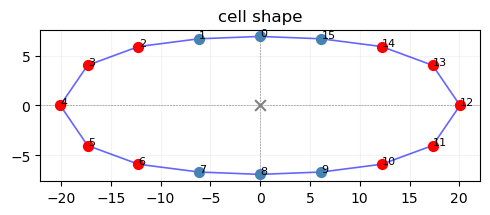

In [5]:
res_wt = run_abm_sim_single(sim_cfg, lut, 3000, 'WT', True)

In [6]:
res_wt['cell_final'], res_wt['springs_final']

({'cell_id': 0,
  'ar': np.float64(2.397),
  'orientation': np.float64(0.0),
  'area_ratio': np.float64(1.0068),
  'mean_rhoa_polar': 0.603,
  'mean_rhoa_lateral': 0.577,
  'mean_rhoc': 0.516,
  'a_sf': 0.871,
  'sf_tension': np.float64(13.495),
  'k_polar': np.float64(1.604),
  'k_lateral': np.float64(1.577),
  'tensile_polar': 35.961,
  'f_total': 10.0},
     id  extension  stiffness  tension  activation
 0    0     1.4776     1.5766   3.3371       0.864
 1    1     1.4342     1.5886   3.3069       0.862
 2    2     0.7639     1.6026   2.2777       0.860
 3    3     0.2146     1.6053   1.4027       0.859
 4    4     0.2146     1.6053   1.4027       0.859
 5    5     0.7639     1.6026   2.2777       0.860
 6    6     1.4342     1.5886   3.3069       0.862
 7    7     1.4776     1.5766   3.3371       0.864
 8    8     1.4776     1.5766   3.3371       0.864
 9    9     1.4342     1.5886   3.3069       0.862
 10  10     0.7639     1.6026   2.2777       0.860
 11  11     0.2146     1.6053

In [ ]:
res_jcad = run_abm_sim_single(jcad_cfg, lut, 3000, 'JCAD', True)

In [ ]:
res_jcad['cell_final'], res_jcad['springs_final']

In [ ]:
res_dsp = run_abm_sim_single(dsp_cfg, lut, 2000, 'DSP', True)

In [ ]:
res_dsp['cell_final'], res_dsp['springs_final']

In [ ]:
res_dsp_jcad = run_abm_sim_single(dsp_jcad_cfg, lut, 2000, 'DSP_JCAD', True)

In [ ]:
res_dsp_jcad['cell_final'], res_dsp_jcad['springs_final']

In [ ]:
res_tjp1 = run_abm_sim_single(tjp1_cfg, lut, 3000, 'TJP1', True)

In [ ]:
res_tjp1['cell_final'], res_tjp1['springs_final']

In [ ]:
res_tjp1_jcad = run_abm_sim_single(tjp1_jcad_cfg, lut, 2000, 'TJP1_JCAD', True)

In [ ]:
res_tjp1_jcad['cell_final'], res_tjp1_jcad['springs_final']

In [7]:
ts_df, ss_df = run_abm_sim(sim_cfg, lut, 3000)

>>> INFO: Running abm simulation perturbation: WT (3000 steps).
{'extension': np.float64(16.1817), 'stiffness': 0.7, 'tension': np.float64(13.4946), 'activation': 0.871, 'axis': array([1., 0.])}
WT                  2.397      0.0°  0.871 
>>> INFO: Running abm simulation perturbation: DSP_KO (3000 steps).
{'extension': np.float64(21.8589), 'stiffness': 0.7, 'tension': np.float64(18.2053), 'activation': 0.827, 'axis': array([ 1., -0.])}
DSP_KO              3.011      0.0°  0.827 
>>> INFO: Running abm simulation perturbation: TJP1_KO (3000 steps).
{'extension': np.float64(11.9637), 'stiffness': 0.7, 'tension': np.float64(9.3291), 'activation': 0.943, 'axis': array([1., 0.])}
TJP1_KO             1.911    180.0°  0.943 
>>> INFO: Running abm simulation perturbation: JCAD_KO (3000 steps).
{'extension': np.float64(17.1532), 'stiffness': 0.7, 'tension': np.float64(13.9243), 'activation': 0.886, 'axis': array([1., 0.])}
JCAD_KO             2.485      0.0°  0.886 
>>> INFO: Running abm simulat

In [ ]:
ss_df